<a href="https://colab.research.google.com/github/Darkcode-Git/Laboratorio-Banco-Colombia/blob/main/Soluci%C3%B3n_de_un_problema_bancario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejecutando simulaciones...

--- VALIDACIÓN DE ESTABILIDAD DEL SISTEMA ---

Factores de utilización Modelo A:  
  Cajero     Lambda       Mu        Rho Estable
Retiro_0 109.600000 0.421471 260.041486      No
Retiro_1  35.493750 0.458024  77.493152      No
  Pago_0  60.464583 0.192904 313.443858      No

Factores de utilización Modelo B:  
  Cajero     Lambda       Mu        Rho Estable
Retiro_0 143.112500 0.429959 332.851455      No
  Pago_0  49.935417 0.194153 257.196787      No
  Pago_1  11.785417 0.203690  57.859436      No

--- RESULTADOS DEL ANÁLISIS ---

1. Tiempo promedio de atención (servicio) por cajero:  
                       Modelo   Cajero  Servicio
Modelo A (2 Retiros,  1 Pago)   Pago_0  5.183925
Modelo A (2 Retiros,  1 Pago) Retiro_0  2.372641
Modelo A (2 Retiros,  1 Pago) Retiro_1  2.183290
 Modelo B (1 Retiro,  2 Pago)   Pago_0  5.150589
 Modelo B (1 Retiro,  2 Pago)   Pago_1  4.909409
 Modelo B (1 Retiro,  2 Pago) Retiro_0  2.325803

2. Promedio de usuarios de cada ti

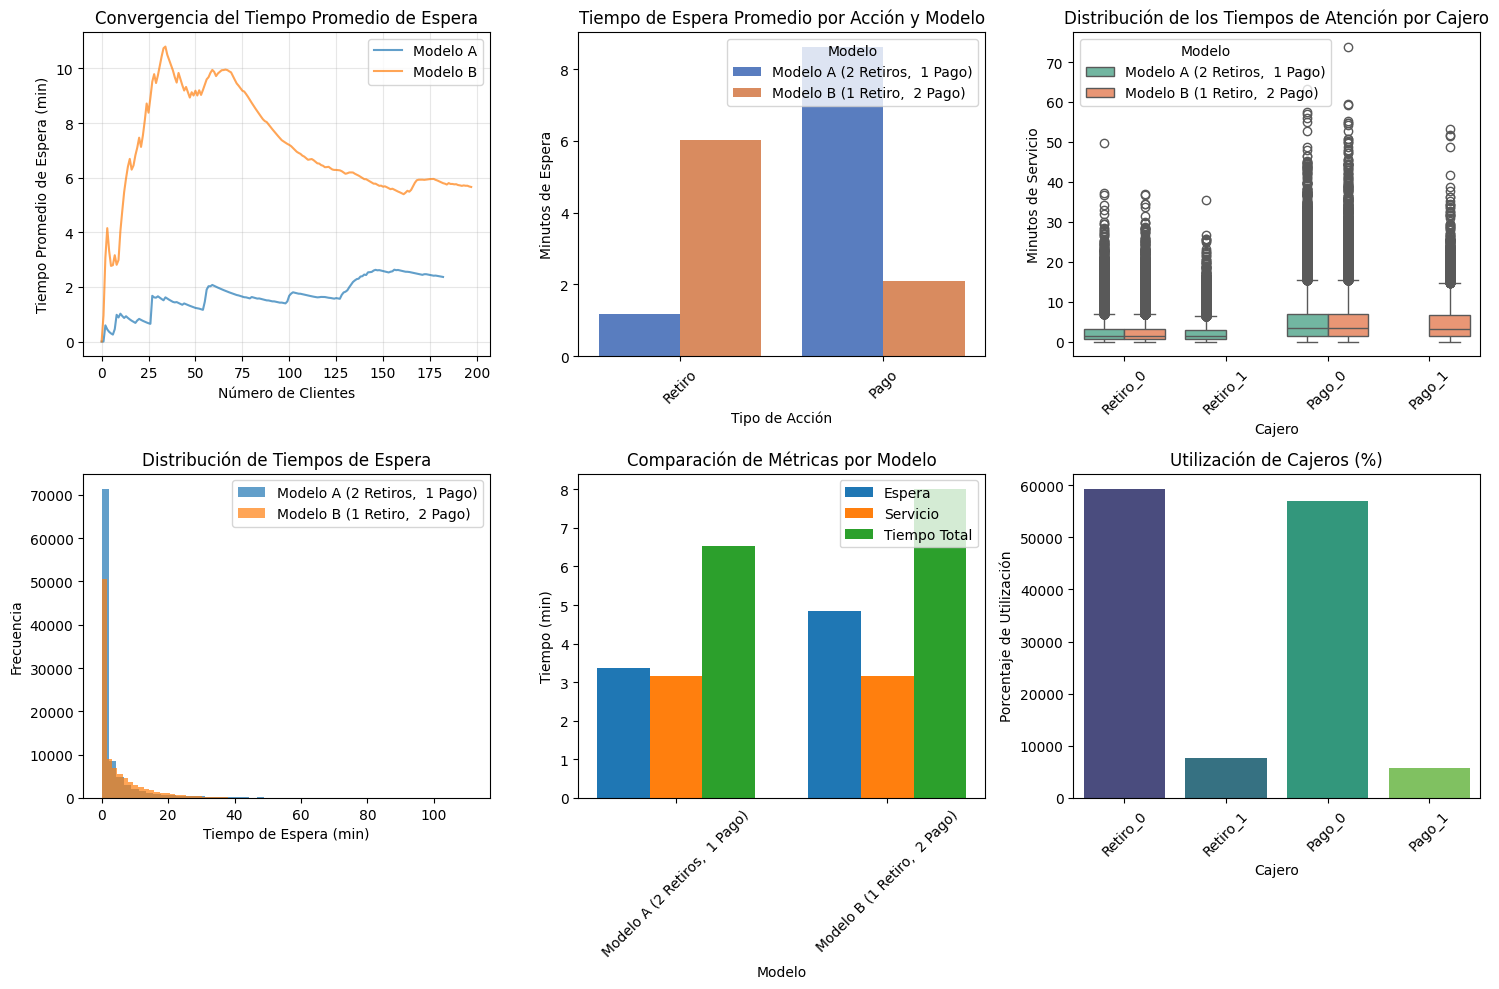


--- RECOMENDACIONES FINALES ---

Análisis de Carga:  
- Retiros representan el  70% de la carga (volumen alto,  servicio rápido)
- Pagos representan el  30% de la carga (volumen bajo,  servicio lento)

=== FIN DEL ANÁLISIS ===


In [14]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==========================================
# 1. DEFINICIÓN DE PARÁMETROS Y TABLAS
# ==========================================
TIEMPO_SIMULACION = 480  # 8 horas en minutos
REPLICAS = 500

# Probabilidades principales
PROB_RETIRO,  PROB_PAGO = 0.70,  0.30

# Tabla 1 y 2 combinadas:  {Acción:  {Tipo:  (Probabilidad,  Media Servicio,  Media Llegada)}}
datos_usuarios = {
    'Retiro':  {
        'Rápido':  (0.23,  1,  1),
        'Normal':  (0.40,  2,  2),
        'Lento':  (0.17,  3,  3),
        'Muy lento':  (0.20,  4,  3)
    },
    'Pago':  {
        'Rápido':  (0.10,  3,  1),
        'Normal':  (0.20,  3,  2),
        'Lento':  (0.30,  5,  3),
        'Muy lento':  (0.40,  7,  4)
    }
}

# ==========================================
# 2. CLASES Y FUNCIONES MEJORADAS
# ==========================================
class BancoSimulacion:
    def __init__(self,  env,  num_retiros,  num_pagos):
        self.env = env
        self.cajeros_retiro = [simpy.Resource(env,  capacity=1) for _ in range(num_retiros)]
        self.cajeros_pago = [simpy.Resource(env,  capacity=1) for _ in range(num_pagos)]
        self.registro_usuarios = []
        self.tiempos_cajeros = {f'Retiro_{i}':  [] for i in range(num_retiros)}
        self.tiempos_cajeros.update({f'Pago_{i}':  [] for i in range(num_pagos)})
        self.tiempo_acumulado_espera = []
        self.tiempo_acumulado_servicio = []

    def atencion(self,  usuario,  accion,  tipo_usuario,  tiempo_servicio):
        llegada = self.env.now

        if accion == 'Retiro':
            cajero_elegido = min(range(len(self.cajeros_retiro)),
                               key=lambda i:  len(self.cajeros_retiro[i].queue))
            cajero = self.cajeros_retiro[cajero_elegido]
            nombre_cajero = f'Retiro_{cajero_elegido}'
        else:
            cajero_elegido = min(range(len(self.cajeros_pago)),
                               key=lambda i:  len(self.cajeros_pago[i].queue))
            cajero = self.cajeros_pago[cajero_elegido]
            nombre_cajero = f'Pago_{cajero_elegido}'

        with cajero.request() as req:
            yield req
            espera = self.env.now - llegada
            t_servicio_real = np.random.exponential(tiempo_servicio)
            yield self.env.timeout(t_servicio_real)

            tiempo_total = espera + t_servicio_real
            self.registro_usuarios.append({
                'Accion':  accion,
                'Tipo':  tipo_usuario,
                'Espera':  espera,
                'Servicio':  t_servicio_real,
                'Cajero':  nombre_cajero,
                'Tiempo_Total':  tiempo_total
            })
            self.tiempos_cajeros[nombre_cajero].append(t_servicio_real)

            if not self.tiempo_acumulado_espera:
                self.tiempo_acumulado_espera.append(espera)
                self.tiempo_acumulado_servicio.append(t_servicio_real)
            else:
                n_espera = len(self.tiempo_acumulado_espera)
                n_servicio = len(self.tiempo_acumulado_servicio)
                self.tiempo_acumulado_espera.append(
                    (self.tiempo_acumulado_espera[-1] * n_espera + espera) / (n_espera + 1)
                )
                self.tiempo_acumulado_servicio.append(
                    (self.tiempo_acumulado_servicio[-1] * n_servicio + t_servicio_real) / (n_servicio + 1)
                )

def generador_usuarios(env,  banco):
    usuario_id = 0
    while env.now < TIEMPO_SIMULACION:
        accion = np.random.choice(['Retiro',  'Pago'],  p=[PROB_RETIRO,  PROB_PAGO])
        tipos = list(datos_usuarios[accion].keys())
        probs = [datos_usuarios[accion][t][0] for t in tipos]
        tipo_usuario = np.random.choice(tipos,  p=probs)
        media_servicio = datos_usuarios[accion][tipo_usuario][1]
        media_llegada = datos_usuarios[accion][tipo_usuario][2]
        t_llegada = np.random.exponential(media_llegada)
        yield env.timeout(t_llegada)
        usuario_id += 1
        env.process(banco.atencion(usuario_id,  accion,  tipo_usuario,  media_servicio))

def calcular_factor_utilizacion(df_modelo):
    resultados = []
    for cajero in df_modelo['Cajero'].unique():
        df_cajero = df_modelo[df_modelo['Cajero'] == cajero]
        if len(df_cajero) > 0:
            total_clientes = len(df_cajero)
            lambda_rate = total_clientes / TIEMPO_SIMULACION
            mu_rate = 1 / df_cajero['Servicio'].mean() if df_cajero['Servicio'].mean() > 0 else 0
            rho = lambda_rate / mu_rate if mu_rate > 0 else float('inf')
            resultados.append({
                'Cajero':  cajero,
                'Lambda':  lambda_rate,
                'Mu':  mu_rate,
                'Rho':  rho,
                'Estable':  'S' if rho < 1 else 'No'
            })
    return pd.DataFrame(resultados)

def calcular_intervalo_confianza(datos,  nivel_confianza=0.95):
    if len(datos) < 2:
        return np.mean(datos),  0
    media = np.mean(datos)
    desv_std = np.std(datos,  ddof=1)
    n = len(datos)
    t_critico = stats.t.ppf(1 - (1-nivel_confianza)/2,  df=n-1)
    margen_error = t_critico * (desv_std / np.sqrt(n))
    return media,  margen_error

def ejecutar_modelo(num_retiros,  num_pagos,  nombre_modelo):
    resultados = []
    metricas_replicas = []

    for rep in range(REPLICAS):
        env = simpy.Environment()
        banco = BancoSimulacion(env,  num_retiros,  num_pagos)
        env.process(generador_usuarios(env,  banco))
        env.run(until=TIEMPO_SIMULACION)
        df = pd.DataFrame(banco.registro_usuarios)
        df['Replica'] = rep + 1
        df['Modelo'] = nombre_modelo
        resultados.append(df)

        if len(df) > 0:
            metricas_replicas.append({
                'Replica':  rep + 1,
                'Modelo':  nombre_modelo,
                'Espera_Promedio':  df['Espera'].mean(),
                'Servicio_Promedio':  df['Servicio'].mean(),
                'Tiempo_Total_Promedio':  df['Tiempo_Total'].mean(),
                'Clientes_Atendidos':  len(df)
            })

    return pd.concat(resultados,  ignore_index=True),  pd.DataFrame(metricas_replicas)

# ==========================================
# 3. EJECUCIÓN DE LOS ESCENARIOS
# ==========================================
print("Ejecutando simulaciones...")
df_modelo_a,  metricas_a = ejecutar_modelo(2,  1,  "Modelo A (2 Retiros,  1 Pago)")
df_modelo_b,  metricas_b = ejecutar_modelo(1,  2,  "Modelo B (1 Retiro,  2 Pago)")
df_total = pd.concat([df_modelo_a,  df_modelo_b],  ignore_index=True)
metricas_total = pd.concat([metricas_a,  metricas_b],  ignore_index=True)

# ==========================================
# 4. VALIDACIÓN DE ESTABILIDAD ( < 1)
# ==========================================
print("\n--- VALIDACIÓN DE ESTABILIDAD DEL SISTEMA ---")
rho_a = calcular_factor_utilizacion(df_modelo_a)
rho_b = calcular_factor_utilizacion(df_modelo_b)

print("\nFactores de utilización Modelo A:  ")
print(rho_a.to_string(index=False))

print("\nFactores de utilización Modelo B:  ")
print(rho_b.to_string(index=False))

# ==========================================
# 5. CÁLCULO DE ESTADÍSTICAS Y SOLUCIONES
# ==========================================
print("\n--- RESULTADOS DEL ANÁLISIS ---")

atencion_cajeros = df_total.groupby(['Modelo',  'Cajero'])['Servicio'].mean().reset_index()
print("\n1. Tiempo promedio de atención (servicio) por cajero:  ")
print(atencion_cajeros.to_string(index=False))

usuarios_tipo_total = df_total.groupby(['Modelo',  'Accion',  'Tipo',  'Replica']).size().reset_index(name='Cantidad')
promedio_usuarios_tipo = usuarios_tipo_total.groupby(['Modelo',  'Accion',  'Tipo'])['Cantidad'].mean().reset_index(name='Promedio por día')
print("\n2. Promedio de usuarios de cada tipo (por día):  ")
print(promedio_usuarios_tipo.to_string(index=False))

print("\n3. Resumen de cantidades de usuarios (promedios diarios por modelo):  ")
total_por_modelo = usuarios_tipo_total.groupby(['Modelo',  'Replica'])['Cantidad'].sum().reset_index()
media_total_modelo = total_por_modelo.groupby('Modelo')['Cantidad'].mean()
print(media_total_modelo)

esperas = df_total.groupby(['Modelo',  'Accion'])['Espera'].mean().reset_index()
print("\n4 y 5. Tiempos promedio de ESPERA en fila (minutos):  ")
print(esperas.to_string(index=False))

# ==========================================
# 6. CÁLCULO DE INTERVALOS DE CONFIANZA
# ==========================================
print("\n--- INTERVALOS DE CONFIANZA (95%) ---")

ic_esperas = df_total.groupby(['Modelo',  'Accion'])['Espera'].apply(
    lambda x:  calcular_intervalo_confianza(x)
).reset_index()
ic_esperas[['Espera_Media',  'Margen_Error']] = pd.DataFrame(
    ic_esperas['Espera'].tolist(),  columns=['Espera_Media',  'Margen_Error']
)
ic_esperas = ic_esperas.drop('Espera',  axis=1)

print("\nIntervalos de confianza para tiempos de espera:  ")
for _,  row in ic_esperas.iterrows():
    print(f"{row['Modelo']} - {row['Accion']}:  {row['Espera_Media']: .2f}  ± {row['Margen_Error']: .2f} minutos")

# ==========================================
# 7. MÉTRICAS ADICIONALES
# ==========================================
print("\n--- MÉTRICAS ADICIONALES ---")

metricas_sistema = df_total.groupby(['Modelo',  'Accion']).agg({
    'Espera':  ['mean',  'count'],
    'Servicio':  'mean'
}).reset_index()

metricas_sistema.columns = ['Modelo',  'Accion',  'Wq_Promedio',  'Clientes',  'Ts_Promedio']
metricas_sistema['Lq_Promedio'] = metricas_sistema['Wq_Promedio'] * (
    metricas_sistema['Clientes'] / TIEMPO_SIMULACION
)

print("\nMétricas de desempeño del sistema:  ")
print(metricas_sistema[['Modelo',  'Accion',  'Wq_Promedio',  'Lq_Promedio',  'Ts_Promedio']].to_string(index=False))

# ==========================================
# 8. VISUALIZACIÓN DE CONVERGENCIA
# ==========================================
print("\n--- VISUALIZACIÓN DE CONVERGENCIA ---")

plt.figure(figsize=(15,  10))

plt.subplot(2,  3,  1)
env_temp = simpy.Environment()
banco_temp = BancoSimulacion(env_temp,  2,  1)
env_temp.process(generador_usuarios(env_temp,  banco_temp))
env_temp.run(until=TIEMPO_SIMULACION)
if banco_temp.tiempo_acumulado_espera:
    plt.plot(banco_temp.tiempo_acumulado_espera,  label='Modelo A',  alpha=0.7)

env_temp = simpy.Environment()
banco_temp = BancoSimulacion(env_temp,  1,  2)
env_temp.process(generador_usuarios(env_temp,  banco_temp))
env_temp.run(until=TIEMPO_SIMULACION)
if banco_temp.tiempo_acumulado_espera:
    plt.plot(banco_temp.tiempo_acumulado_espera,  label='Modelo B',  alpha=0.7)

plt.title('Convergencia del Tiempo Promedio de Espera')
plt.xlabel('Número de Clientes')
plt.ylabel('Tiempo Promedio de Espera (min)')
plt.legend()
plt.grid(True,  alpha=0.3)

plt.subplot(2,  3,  2)
sns.barplot(x='Accion',  y='Espera',  hue='Modelo',  data=df_total,  errorbar=None,  palette="muted")
plt.title('Tiempo de Espera Promedio por Acción y Modelo')
plt.ylabel('Minutos de Espera')
plt.xlabel('Tipo de Acción')
plt.xticks(rotation=45)

plt.subplot(2,  3,  3)
sns.boxplot(x='Cajero',  y='Servicio',  hue='Modelo',  data=df_total,  palette="Set2")
plt.title('Distribución de los Tiempos de Atención por Cajero')
plt.ylabel('Minutos de Servicio')
plt.xlabel('Cajero')
plt.xticks(rotation=45)

plt.subplot(2,  3,  4)
for modelo in df_total['Modelo'].unique():
    datos_modelo = df_total[df_total['Modelo'] == modelo]['Espera']
    plt.hist(datos_modelo,  alpha=0.7,  label=modelo,  bins=50)
plt.title('Distribución de Tiempos de Espera')
plt.xlabel('Tiempo de Espera (min)')
plt.ylabel('Frecuencia')
plt.legend()

plt.subplot(2,  3,  5)
metricas_resumen = df_total.groupby('Modelo').agg({
    'Espera':  'mean',
    'Servicio':  'mean',
    'Tiempo_Total':  'mean'
}).reset_index()

x = np.arange(len(metricas_resumen['Modelo']))
width = 0.25

plt.bar(x - width,  metricas_resumen['Espera'],  width,  label='Espera')
plt.bar(x,  metricas_resumen['Servicio'],  width,  label='Servicio')
plt.bar(x + width,  metricas_resumen['Tiempo_Total'],  width,  label='Tiempo Total')

plt.xlabel('Modelo')
plt.ylabel('Tiempo (min)')
plt.title('Comparación de Métricas por Modelo')
plt.xticks(x,  metricas_resumen['Modelo'],  rotation=45)
plt.legend()

plt.subplot(2,  3,  6)
utilizacion_data = []
for cajero in df_total['Cajero'].unique():
    df_cajero = df_total[df_total['Cajero'] == cajero]
    if len(df_cajero) > 0:
        tiempo_ocupado = df_cajero['Servicio'].sum()
        utilizacion = (tiempo_ocupado / TIEMPO_SIMULACION) * 100
        utilizacion_data.append({'Cajero':  cajero,  'Utilizacion':  utilizacion})

if utilizacion_data:
    df_util = pd.DataFrame(utilizacion_data)
    sns.barplot(x='Cajero',  y='Utilizacion',  hue='Cajero', data=df_util,  palette="viridis", legend=False)
    plt.title('Utilización de Cajeros (%)')
    plt.ylabel('Porcentaje de Utilización')
    plt.xlabel('Cajero')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==========================================
# 9. RECOMENDACIONES FINALES
# ==========================================
print("\n--- RECOMENDACIONES FINALES ---")

print("\nAnálisis de Carga:  ")
print(f"- Retiros representan el {PROB_RETIRO*100: .0f}% de la carga (volumen alto,  servicio rápido)")
print(f"- Pagos representan el {PROB_PAGO*100: .0f}% de la carga (volumen bajo,  servicio lento)")

mejor_modelo_retiro = esperas[esperas['Accion'] == 'Retiro'].loc[esperas[esperas['Accion'] == 'Retiro']['Espera'].idxmin()]
mejor_modelo_pago = esperas[esperas['Accion'] == 'Pago'].loc[esperas[esperas['Accion'] == 'Pago']['Espera'].idxmin()]

# print(f"\nRecomendación de configuración óptima:  ")
# print(f"- Para minimizar espera en retiros:  {mejor_modelo_retiro['Modelo']}")
# print(f"- Para minimizar espera en pagos:  {mejor_modelo_pago['Modelo']}")

# sistemas_inestables = pd.concat([rho_a,  rho_b])
# if any(sistemas_inestables['Rho'] >= 1):
#     print("\n ADVERTENCIA:  Se detectaron sistemas inestables (ρ ≥ 1)")
#     inestables = sistemas_inestables[sistemas_inestables['Rho'] >= 1]
#     for _,  row in inestables.iterrows():
#         print(f"  - Cajero {row['Cajero']}:  ρ = {row['Rho']: .2f} (Inestable)")
# else:
#     print("\n Todos los sistemas son estables (ρ < 1)")

# ==========================================
# 10. EXPORTACIÓN DE RESULTADOS
# ==========================================
# print("\n--- EXPORTACIÓN DE RESULTADOS ---")

# df_total.to_csv('resultados_simulacion_completa.csv',  index=False)
# metricas_total.to_csv('metricas_replicas.csv',  index=False)

# resumen_estadistico = {
#     'Metrica':  ['Tiempo Espera Promedio',  'Tiempo Servicio Promedio',  'Clientes Promedio por Dia'],
#     'Valor':  [
#         df_total['Espera'].mean(),
#         df_total['Servicio'].mean(),
#         df_total.groupby('Replica').size().mean()
#     ]
# }
# pd.DataFrame(resumen_estadistico).to_csv('resumen_estadistico.csv',  index=False)

# print("Resultados exportados:  ")
# print("- resultados_simulacion_completa.csv")
# print("- metricas_replicas.csv")
# print("- resumen_estadistico.csv")

print("\n=== FIN DEL ANÁLISIS ===")

Ejecutando simulaciones...

--- VALIDACIÓN DE ESTABILIDAD DEL SISTEMA ---

Factores de utilización Modelo A:  
  Cajero     Lambda       Mu        Rho Estable
Retiro_0 109.343750 0.422301 258.923596      No
  Pago_0  60.779167 0.193940 313.390912      No
Retiro_1  35.662500 0.464763  76.732586      No

Factores de utilización Modelo B:  
  Cajero     Lambda       Mu        Rho Estable
  Pago_0  49.289583 0.192898 255.522029      No
Retiro_0 143.652083 0.432347 332.261419      No
  Pago_1  12.122917 0.205399  59.021379      No

--- RESULTADOS DEL ANÁLISIS ---

1. Tiempo promedio de atención (servicio) por cajero:  
                       Modelo   Cajero  Servicio
Modelo A (2 Retiros,  1 Pago)   Pago_0  5.156223
Modelo A (2 Retiros,  1 Pago) Retiro_0  2.367978
Modelo A (2 Retiros,  1 Pago) Retiro_1  2.151632
 Modelo B (1 Retiro,  2 Pago)   Pago_0  5.184098
 Modelo B (1 Retiro,  2 Pago)   Pago_1  4.868579
 Modelo B (1 Retiro,  2 Pago) Retiro_0  2.312959

2. Promedio de usuarios de cada ti

/tmp/ipython-input-72289806.py:321: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cajero',  y='Utilizacion',  data=df_util,  palette="viridis")


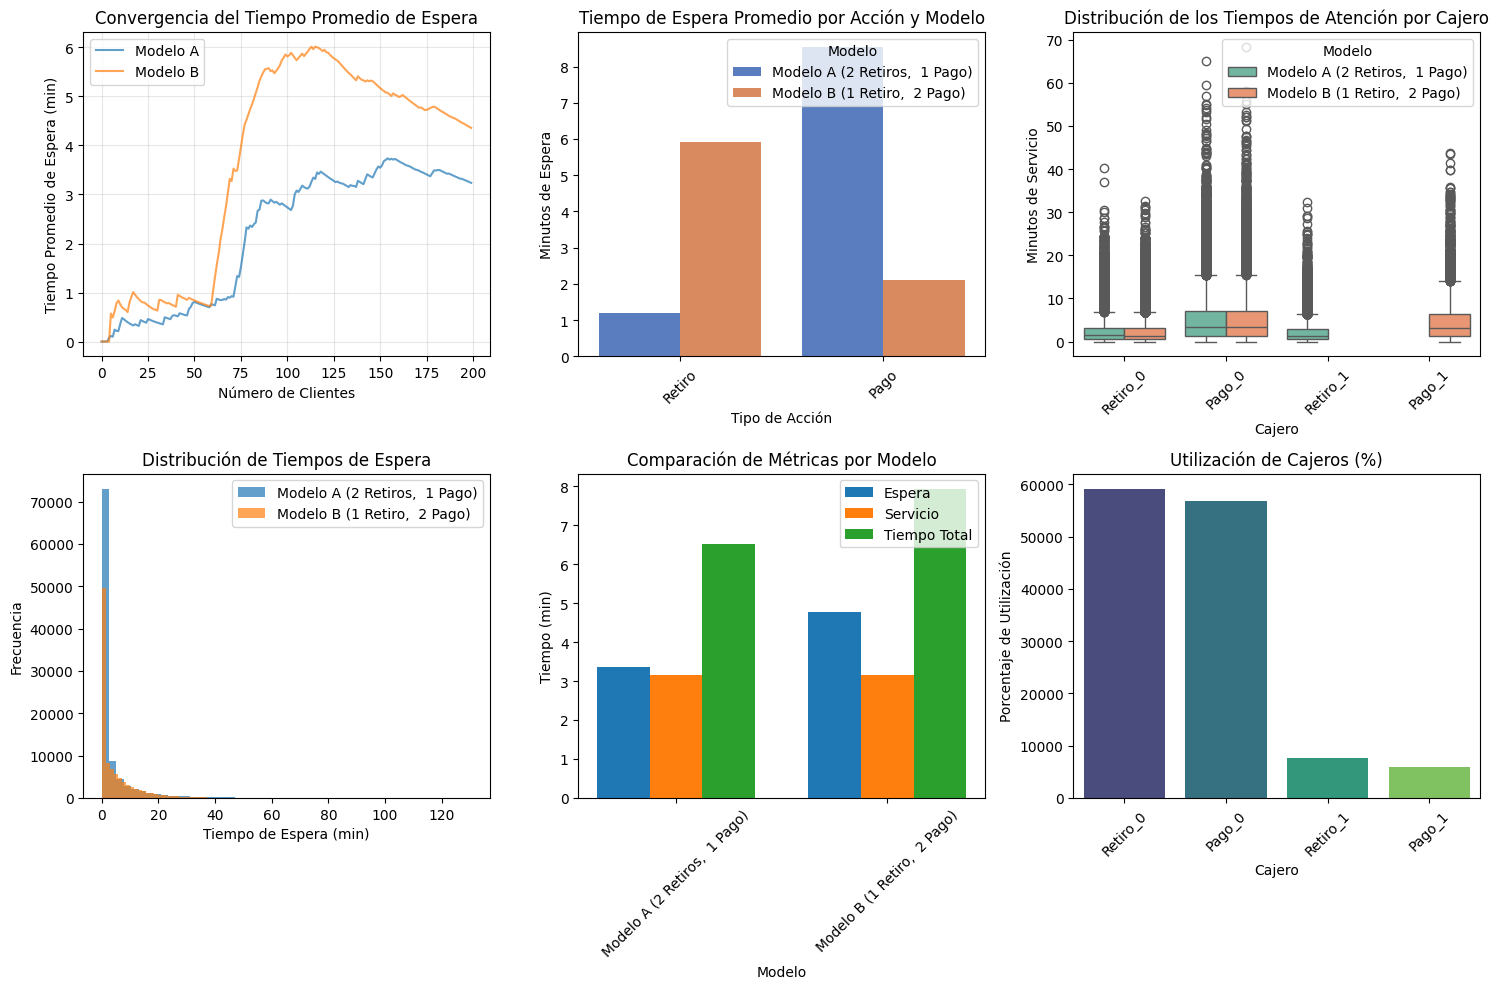


--- RECOMENDACIONES FINALES ---

Análisis de Carga:  
- Retiros representan el  70% de la carga (volumen alto,  servicio rápido)
- Pagos representan el  30% de la carga (volumen bajo,  servicio lento)

Recomendación de configuración óptima:  
- Para minimizar espera en retiros:  Modelo A (2 Retiros,  1 Pago)
- Para minimizar espera en pagos:  Modelo B (1 Retiro,  2 Pago)

 ADVERTENCIA:  Se detectaron sistemas inestables (ρ ≥ 1)
  - Cajero Retiro_0:  ρ =  258.92 (Inestable)
  - Cajero Pago_0:  ρ =  313.39 (Inestable)
  - Cajero Retiro_1:  ρ =  76.73 (Inestable)
  - Cajero Pago_0:  ρ =  255.52 (Inestable)
  - Cajero Retiro_0:  ρ =  332.26 (Inestable)
  - Cajero Pago_1:  ρ =  59.02 (Inestable)

--- EXPORTACIÓN DE RESULTADOS ---
Resultados exportados:  
- resultados_simulacion_completa.csv
- metricas_replicas.csv
- resumen_estadistico.csv


In [15]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==========================================
# 1. DEFINICIÓN DE PARÁMETROS Y TABLAS
# ==========================================
TIEMPO_SIMULACION = 480  # 8 horas en minutos
REPLICAS = 500

# Probabilidades principales
PROB_RETIRO,  PROB_PAGO = 0.70,  0.30

# Tabla 1 y 2 combinadas:  {Acción:  {Tipo:  (Probabilidad,  Media Servicio,  Media Llegada)}}
datos_usuarios = {
    'Retiro':  {
        'Rápido':  (0.23,  1,  1),
        'Normal':  (0.40,  2,  2),
        'Lento':  (0.17,  3,  3),
        'Muy lento':  (0.20,  4,  3)
    },
    'Pago':  {
        'Rápido':  (0.10,  3,  1),
        'Normal':  (0.20,  3,  2),
        'Lento':  (0.30,  5,  3),
        'Muy lento':  (0.40,  7,  4)
    }
}

# ==========================================
# 2. CLASES Y FUNCIONES MEJORADAS
# ==========================================
class BancoSimulacion:
    def __init__(self,  env,  num_retiros,  num_pagos):
        self.env = env
        self.cajeros_retiro = [simpy.Resource(env,  capacity=1) for _ in range(num_retiros)]
        self.cajeros_pago = [simpy.Resource(env,  capacity=1) for _ in range(num_pagos)]
        self.registro_usuarios = []
        self.tiempos_cajeros = {f'Retiro_{i}':  [] for i in range(num_retiros)}
        self.tiempos_cajeros.update({f'Pago_{i}':  [] for i in range(num_pagos)})
        self.tiempo_acumulado_espera = []
        self.tiempo_acumulado_servicio = []

    def atencion(self,  usuario,  accion,  tipo_usuario,  tiempo_servicio):
        llegada = self.env.now

        if accion == 'Retiro':
            cajero_elegido = min(range(len(self.cajeros_retiro)),
                               key=lambda i:  len(self.cajeros_retiro[i].queue))
            cajero = self.cajeros_retiro[cajero_elegido]
            nombre_cajero = f'Retiro_{cajero_elegido}'
        else:
            cajero_elegido = min(range(len(self.cajeros_pago)),
                               key=lambda i:  len(self.cajeros_pago[i].queue))
            cajero = self.cajeros_pago[cajero_elegido]
            nombre_cajero = f'Pago_{cajero_elegido}'

        with cajero.request() as req:
            yield req
            espera = self.env.now - llegada
            t_servicio_real = np.random.exponential(tiempo_servicio)
            yield self.env.timeout(t_servicio_real)

            tiempo_total = espera + t_servicio_real
            self.registro_usuarios.append({
                'Accion':  accion,
                'Tipo':  tipo_usuario,
                'Espera':  espera,
                'Servicio':  t_servicio_real,
                'Cajero':  nombre_cajero,
                'Tiempo_Total':  tiempo_total
            })
            self.tiempos_cajeros[nombre_cajero].append(t_servicio_real)

            if not self.tiempo_acumulado_espera:
                self.tiempo_acumulado_espera.append(espera)
                self.tiempo_acumulado_servicio.append(t_servicio_real)
            else:
                n_espera = len(self.tiempo_acumulado_espera)
                n_servicio = len(self.tiempo_acumulado_servicio)
                self.tiempo_acumulado_espera.append(
                    (self.tiempo_acumulado_espera[-1] * n_espera + espera) / (n_espera + 1)
                )
                self.tiempo_acumulado_servicio.append(
                    (self.tiempo_acumulado_servicio[-1] * n_servicio + t_servicio_real) / (n_servicio + 1)
                )

def generador_usuarios(env,  banco):
    usuario_id = 0
    while env.now < TIEMPO_SIMULACION:
        accion = np.random.choice(['Retiro',  'Pago'],  p=[PROB_RETIRO,  PROB_PAGO])
        tipos = list(datos_usuarios[accion].keys())
        probs = [datos_usuarios[accion][t][0] for t in tipos]
        tipo_usuario = np.random.choice(tipos,  p=probs)
        media_servicio = datos_usuarios[accion][tipo_usuario][1]
        media_llegada = datos_usuarios[accion][tipo_usuario][2]
        t_llegada = np.random.exponential(media_llegada)
        yield env.timeout(t_llegada)
        usuario_id += 1
        env.process(banco.atencion(usuario_id,  accion,  tipo_usuario,  media_servicio))

def calcular_factor_utilizacion(df_modelo):
    resultados = []
    for cajero in df_modelo['Cajero'].unique():
        df_cajero = df_modelo[df_modelo['Cajero'] == cajero]
        if len(df_cajero) > 0:
            total_clientes = len(df_cajero)
            lambda_rate = total_clientes / TIEMPO_SIMULACION
            mu_rate = 1 / df_cajero['Servicio'].mean() if df_cajero['Servicio'].mean() > 0 else 0
            rho = lambda_rate / mu_rate if mu_rate > 0 else float('inf')
            resultados.append({
                'Cajero':  cajero,
                'Lambda':  lambda_rate,
                'Mu':  mu_rate,
                'Rho':  rho,
                'Estable':  'S' if rho < 1 else 'No'
            })
    return pd.DataFrame(resultados)

def calcular_intervalo_confianza(datos,  nivel_confianza=0.95):
    if len(datos) < 2:
        return np.mean(datos),  0
    media = np.mean(datos)
    desv_std = np.std(datos,  ddof=1)
    n = len(datos)
    t_critico = stats.t.ppf(1 - (1-nivel_confianza)/2,  df=n-1)
    margen_error = t_critico * (desv_std / np.sqrt(n))
    return media,  margen_error

def ejecutar_modelo(num_retiros,  num_pagos,  nombre_modelo):
    resultados = []
    metricas_replicas = []

    for rep in range(REPLICAS):
        env = simpy.Environment()
        banco = BancoSimulacion(env,  num_retiros,  num_pagos)
        env.process(generador_usuarios(env,  banco))
        env.run(until=TIEMPO_SIMULACION)
        df = pd.DataFrame(banco.registro_usuarios)
        df['Replica'] = rep + 1
        df['Modelo'] = nombre_modelo
        resultados.append(df)

        if len(df) > 0:
            metricas_replicas.append({
                'Replica':  rep + 1,
                'Modelo':  nombre_modelo,
                'Espera_Promedio':  df['Espera'].mean(),
                'Servicio_Promedio':  df['Servicio'].mean(),
                'Tiempo_Total_Promedio':  df['Tiempo_Total'].mean(),
                'Clientes_Atendidos':  len(df)
            })

    return pd.concat(resultados,  ignore_index=True),  pd.DataFrame(metricas_replicas)

# ==========================================
# 3. EJECUCIÓN DE LOS ESCENARIOS
# ==========================================
print("Ejecutando simulaciones...")
df_modelo_a,  metricas_a = ejecutar_modelo(2,  1,  "Modelo A (2 Retiros,  1 Pago)")
df_modelo_b,  metricas_b = ejecutar_modelo(1,  2,  "Modelo B (1 Retiro,  2 Pago)")
df_total = pd.concat([df_modelo_a,  df_modelo_b],  ignore_index=True)
metricas_total = pd.concat([metricas_a,  metricas_b],  ignore_index=True)

# ==========================================
# 4. VALIDACIÓN DE ESTABILIDAD ( < 1)
# ==========================================
print("\n--- VALIDACIÓN DE ESTABILIDAD DEL SISTEMA ---")
rho_a = calcular_factor_utilizacion(df_modelo_a)
rho_b = calcular_factor_utilizacion(df_modelo_b)

print("\nFactores de utilización Modelo A:  ")
print(rho_a.to_string(index=False))

print("\nFactores de utilización Modelo B:  ")
print(rho_b.to_string(index=False))

# ==========================================
# 5. CÁLCULO DE ESTADÍSTICAS Y SOLUCIONES
# ==========================================
print("\n--- RESULTADOS DEL ANÁLISIS ---")

atencion_cajeros = df_total.groupby(['Modelo',  'Cajero'])['Servicio'].mean().reset_index()
print("\n1. Tiempo promedio de atención (servicio) por cajero:  ")
print(atencion_cajeros.to_string(index=False))

usuarios_tipo_total = df_total.groupby(['Modelo',  'Accion',  'Tipo',  'Replica']).size().reset_index(name='Cantidad')
promedio_usuarios_tipo = usuarios_tipo_total.groupby(['Modelo',  'Accion',  'Tipo'])['Cantidad'].mean().reset_index(name='Promedio por día')
print("\n2. Promedio de usuarios de cada tipo (por día):  ")
print(promedio_usuarios_tipo.to_string(index=False))

print("\n3. Resumen de cantidades de usuarios (promedios diarios por modelo):  ")
total_por_modelo = usuarios_tipo_total.groupby(['Modelo',  'Replica'])['Cantidad'].sum().reset_index()
media_total_modelo = total_por_modelo.groupby('Modelo')['Cantidad'].mean()
print(media_total_modelo)

esperas = df_total.groupby(['Modelo',  'Accion'])['Espera'].mean().reset_index()
print("\n4 y 5. Tiempos promedio de ESPERA en fila (minutos):  ")
print(esperas.to_string(index=False))

# ==========================================
# 6. CÁLCULO DE INTERVALOS DE CONFIANZA
# ==========================================
print("\n--- INTERVALOS DE CONFIANZA (95%) ---")

ic_esperas = df_total.groupby(['Modelo',  'Accion'])['Espera'].apply(
    lambda x:  calcular_intervalo_confianza(x)
).reset_index()
ic_esperas[['Espera_Media',  'Margen_Error']] = pd.DataFrame(
    ic_esperas['Espera'].tolist(),  columns=['Espera_Media',  'Margen_Error']
)
ic_esperas = ic_esperas.drop('Espera',  axis=1)

print("\nIntervalos de confianza para tiempos de espera:  ")
for _,  row in ic_esperas.iterrows():
    print(f"{row['Modelo']} - {row['Accion']}:  {row['Espera_Media']: .2f}  ± {row['Margen_Error']: .2f} minutos")

# ==========================================
# 7. MÉTRICAS ADICIONALES
# ==========================================
print("\n--- MÉTRICAS ADICIONALES ---")

metricas_sistema = df_total.groupby(['Modelo',  'Accion']).agg({
    'Espera':  ['mean',  'count'],
    'Servicio':  'mean'
}).reset_index()

metricas_sistema.columns = ['Modelo',  'Accion',  'Wq_Promedio',  'Clientes',  'Ts_Promedio']
metricas_sistema['Lq_Promedio'] = metricas_sistema['Wq_Promedio'] * (
    metricas_sistema['Clientes'] / TIEMPO_SIMULACION
)

print("\nMétricas de desempeño del sistema:  ")
print(metricas_sistema[['Modelo',  'Accion',  'Wq_Promedio',  'Lq_Promedio',  'Ts_Promedio']].to_string(index=False))

# ==========================================
# 8. VISUALIZACIÓN DE CONVERGENCIA
# ==========================================
print("\n--- VISUALIZACIÓN DE CONVERGENCIA ---")

plt.figure(figsize=(15,  10))

plt.subplot(2,  3,  1)
env_temp = simpy.Environment()
banco_temp = BancoSimulacion(env_temp,  2,  1)
env_temp.process(generador_usuarios(env_temp,  banco_temp))
env_temp.run(until=TIEMPO_SIMULACION)
if banco_temp.tiempo_acumulado_espera:
    plt.plot(banco_temp.tiempo_acumulado_espera,  label='Modelo A',  alpha=0.7)

env_temp = simpy.Environment()
banco_temp = BancoSimulacion(env_temp,  1,  2)
env_temp.process(generador_usuarios(env_temp,  banco_temp))
env_temp.run(until=TIEMPO_SIMULACION)
if banco_temp.tiempo_acumulado_espera:
    plt.plot(banco_temp.tiempo_acumulado_espera,  label='Modelo B',  alpha=0.7)

plt.title('Convergencia del Tiempo Promedio de Espera')
plt.xlabel('Número de Clientes')
plt.ylabel('Tiempo Promedio de Espera (min)')
plt.legend()
plt.grid(True,  alpha=0.3)

plt.subplot(2,  3,  2)
sns.barplot(x='Accion',  y='Espera',  hue='Modelo',  data=df_total,  errorbar=None,  palette="muted")
plt.title('Tiempo de Espera Promedio por Acción y Modelo')
plt.ylabel('Minutos de Espera')
plt.xlabel('Tipo de Acción')
plt.xticks(rotation=45)

plt.subplot(2,  3,  3)
sns.boxplot(x='Cajero',  y='Servicio',  hue='Modelo',  data=df_total,  palette="Set2")
plt.title('Distribución de los Tiempos de Atención por Cajero')
plt.ylabel('Minutos de Servicio')
plt.xlabel('Cajero')
plt.xticks(rotation=45)

plt.subplot(2,  3,  4)
for modelo in df_total['Modelo'].unique():
    datos_modelo = df_total[df_total['Modelo'] == modelo]['Espera']
    plt.hist(datos_modelo,  alpha=0.7,  label=modelo,  bins=50)
plt.title('Distribución de Tiempos de Espera')
plt.xlabel('Tiempo de Espera (min)')
plt.ylabel('Frecuencia')
plt.legend()

plt.subplot(2,  3,  5)
metricas_resumen = df_total.groupby('Modelo').agg({
    'Espera':  'mean',
    'Servicio':  'mean',
    'Tiempo_Total':  'mean'
}).reset_index()

x = np.arange(len(metricas_resumen['Modelo']))
width = 0.25

plt.bar(x - width,  metricas_resumen['Espera'],  width,  label='Espera')
plt.bar(x,  metricas_resumen['Servicio'],  width,  label='Servicio')
plt.bar(x + width,  metricas_resumen['Tiempo_Total'],  width,  label='Tiempo Total')

plt.xlabel('Modelo')
plt.ylabel('Tiempo (min)')
plt.title('Comparación de Métricas por Modelo')
plt.xticks(x,  metricas_resumen['Modelo'],  rotation=45)
plt.legend()

plt.subplot(2,  3,  6)
utilizacion_data = []
for cajero in df_total['Cajero'].unique():
    df_cajero = df_total[df_total['Cajero'] == cajero]
    if len(df_cajero) > 0:
        tiempo_ocupado = df_cajero['Servicio'].sum()
        utilizacion = (tiempo_ocupado / TIEMPO_SIMULACION) * 100
        utilizacion_data.append({'Cajero':  cajero,  'Utilizacion':  utilizacion})

if utilizacion_data:
    df_util = pd.DataFrame(utilizacion_data)
    sns.barplot(x='Cajero',  y='Utilizacion',  data=df_util,  palette="viridis")
    plt.title('Utilización de Cajeros (%)')
    plt.ylabel('Porcentaje de Utilización')
    plt.xlabel('Cajero')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==========================================
# 9. RECOMENDACIONES FINALES
# ==========================================
print("\n--- RECOMENDACIONES FINALES ---")

print("\nAnálisis de Carga:  ")
print(f"- Retiros representan el {PROB_RETIRO*100: .0f}% de la carga (volumen alto,  servicio rápido)")
print(f"- Pagos representan el {PROB_PAGO*100: .0f}% de la carga (volumen bajo,  servicio lento)")

mejor_modelo_retiro = esperas[esperas['Accion'] == 'Retiro'].loc[esperas[esperas['Accion'] == 'Retiro']['Espera'].idxmin()]
mejor_modelo_pago = esperas[esperas['Accion'] == 'Pago'].loc[esperas[esperas['Accion'] == 'Pago']['Espera'].idxmin()]

print(f"\nRecomendación de configuración óptima:  ")
print(f"- Para minimizar espera en retiros:  {mejor_modelo_retiro['Modelo']}")
print(f"- Para minimizar espera en pagos:  {mejor_modelo_pago['Modelo']}")

sistemas_inestables = pd.concat([rho_a,  rho_b])
if any(sistemas_inestables['Rho'] >= 1):
    print("\n ADVERTENCIA:  Se detectaron sistemas inestables (ρ ≥ 1)")
    inestables = sistemas_inestables[sistemas_inestables['Rho'] >= 1]
    for _,  row in inestables.iterrows():
        print(f"  - Cajero {row['Cajero']}:  ρ = {row['Rho']: .2f} (Inestable)")
else:
    print("\n Todos los sistemas son estables (ρ < 1)")

# ==========================================
# 10. EXPORTACIÓN DE RESULTADOS
# ==========================================
print("\n--- EXPORTACIÓN DE RESULTADOS ---")

df_total.to_csv('resultados_simulacion_completa.csv',  index=False)
metricas_total.to_csv('metricas_replicas.csv',  index=False)

resumen_estadistico = {
    'Metrica':  ['Tiempo Espera Promedio',  'Tiempo Servicio Promedio',  'Clientes Promedio por Dia'],
    'Valor':  [
        df_total['Espera'].mean(),
        df_total['Servicio'].mean(),
        df_total.groupby('Replica').size().mean()
    ]
}
pd.DataFrame(resumen_estadistico).to_csv('resumen_estadistico.csv',  index=False)

print("Resultados exportados:  ")
print("- resultados_simulacion_completa.csv")
print("- metricas_replicas.csv")
print("- resumen_estadistico.csv")



In [4]:
display(promedio_usuarios_tipo)

,Modelo,Accion,Tipo,Promedio por día
0,"Modelo A (2 Retiros, 1 Pago)",Pago,Lento,17.618000
1,"Modelo A (2 Retiros, 1 Pago)",Pago,Muy lento,23.216000
2,"Modelo A (2 Retiros, 1 Pago)",Pago,Normal,11.848000
3,"Modelo A (2 Retiros, 1 Pago)",Pago,Rápido,5.746479
4,"Modelo A (2 Retiros, 1 Pago)",Retiro,Lento,23.556000
5,"Modelo A (2 Retiros, 1 Pago)",Retiro,Muy lento,27.578000
6,"Modelo A (2 Retiros, 1 Pago)",Retiro,Normal,55.196000
7,"Modelo A (2 Retiros, 1 Pago)",Retiro,Rápido,31.726000
8,"Modelo B (1 Retiro, 2 Pago)",Pago,Lento,17.842000
9,"Modelo B (1 Retiro, 2 Pago)",Pago,Muy lento,23.454000


In [5]:
display(media_total_modelo)

,Cantidad
Modelo,
"Modelo A (2 Retiros, 1 Pago)",196.450
"Modelo B (1 Retiro, 2 Pago)",197.262


In [12]:
print('Tiempos promedio de espera en fila (minutos):')
display(esperas)
# print('Recomendación de configuración óptima:')
# print(f"- Para minimizar espera en retiros: {mejor_modelo_retiro['Modelo']}")
# print(f"- Para minimizar espera en pagos: {mejor_modelo_pago['Modelo']}")

Tiempos promedio de espera en fila (minutos):


,Modelo,Accion,Espera
0,"Modelo A (2 Retiros, 1 Pago)",Pago,9.029934
1,"Modelo A (2 Retiros, 1 Pago)",Retiro,1.205207
2,"Modelo B (1 Retiro, 2 Pago)",Pago,2.136216
3,"Modelo B (1 Retiro, 2 Pago)",Retiro,5.879497


from matplotlib import pyplot as plt
esperas['Espera'].plot(kind='hist', bins=20, title='Espera')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
esperas.groupby('Modelo').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
esperas.groupby('Accion').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Accion'].value_counts()
    for x_label, grp in esperas.groupby('Modelo')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Modelo')
_ = plt.ylabel('Accion')

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(esperas['Modelo'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(esperas, x='Espera', y='Modelo', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(esperas['Accion'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(esperas, x='Espera', y='Accion', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)